# Рекомендательная система — Sprint 4

**Структура работы**

| Этап | Что делаем в ноутбуке | Где лежат результаты |
|------|------------------------|----------------------|
| **1** | EDA, очистка `interactions`, приведение типов | `data/interactions_clean.parquet` |
| **2** | EDA по событиям, формирование каталога и истории | `items.parquet`, `events.parquet` -> S3 `recsys/data/` |
| **3** | Топ популярных, ALS, похожие треки, CatBoost-ранжирование, метрики | см. таблицу ниже -> S3 `recsys/recommendations/` |

**Файлы рекомендаций (локально и в S3 `recsys/recommendations/`)**

| Файл | Содержимое |
|------|------------|
| `top_popular.parquet` | 100 самых популярных треков (`rank`, `item_id`, `plays`, метаданные, `score`) |
| `personal_als.parquet` | Персональные рекомендации ALS: до 50 треков на пользователя (`user_id`, `item_id`, `score`) |
| `similar.parquet` | Похожие треки для item-item (`item_id_1`, `item_id_2`, `score`) |
| `recommendations.parquet` | Итоговые рекомендации после CatBoost: до 50 треков на пользователя (`user_id`, `item_id`, `score`) |

Дополнительно: `metrics_summary.csv` (precision, recall, coverage, novelty @5), модель `models/cb_model.cbm`.

> **Примечание.** Расчёт этапа 3 на полном объёме данных выполнен вспомогательным скриптом `scripts/build_recommendations.py` из‑за лимита RAM (8 GB). В ноутбуке — EDA, подготовка данных и демонстрация готовых результатов (parquet в S3). На слабой VM не запускайте **Run All** без необходимости — outputs уже сохранены.

In [15]:
for path, key in [
    ("items.parquet", "recsys/data/items.parquet"),
    ("events.parquet", "recsys/data/events.parquet"),
    ("top_popular.parquet", "recsys/recommendations/top_popular.parquet"),
    ("personal_als.parquet", "recsys/recommendations/personal_als.parquet"),
    ("similar.parquet", "recsys/recommendations/similar.parquet"),
    ("recommendations.parquet", "recsys/recommendations/recommendations.parquet"),
]:
    s3_client.upload_file(path, S3_BUCKET, key)
    print(f"uploaded s3://{S3_BUCKET}/{key}")



uploaded s3://s3-student-mle-20260402-054cf46b48/recsys/data/items.parquet
uploaded s3://s3-student-mle-20260402-054cf46b48/recsys/data/events.parquet
uploaded s3://s3-student-mle-20260402-054cf46b48/recsys/recommendations/top_popular.parquet
uploaded s3://s3-student-mle-20260402-054cf46b48/recsys/recommendations/personal_als.parquet
uploaded s3://s3-student-mle-20260402-054cf46b48/recsys/recommendations/similar.parquet
uploaded s3://s3-student-mle-20260402-054cf46b48/recsys/recommendations/recommendations.parquet


# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [ ]:
import os
import gc
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.sparse
import sklearn.preprocessing
import boto3
from dotenv import load_dotenv
from catboost import CatBoostClassifier, Pool
from implicit.als import AlternatingLeastSquares

load_dotenv()

pl.Config.set_tbl_rows(10)
np.random.seed(42)
pd.set_option("display.max_columns", 50)

session = boto3.session.Session()
s3_client = session.client(
    service_name="s3",
    endpoint_url=os.environ.get("S3_ENDPOINT_URL", "https://storage.yandexcloud.net"),
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
S3_BUCKET = os.environ["S3_BUCKET_NAME"]
os.makedirs("models", exist_ok=True)

/home/mle-user/mle-project-sprint-4-v001/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pl.read_parquet("data/tracks.parquet")
catalog_names = pl.read_parquet("data/catalog_names.parquet")

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
tracks.head(3)

tracks: (1000000, 4)
catalog_names: (1812471, 3)


track_id,albums,artists,genres
i64,list[i64],list[i64],list[i64]
26,"[3, 2490753]",[16],"[11, 21]"
38,"[3, 2490753]",[16],"[11, 21]"
135,"[12, 214, 2490809]",[84],[11]


In [3]:
events_lazy = pl.scan_parquet("data/interactions.parquet")

print("schema:", events_lazy.collect_schema())
print("число событий:", events_lazy.select(pl.len()).collect().item())
events_lazy.head(3).collect()

schema: Schema([('user_id', Int32), ('track_id', Int32), ('track_seq', Int16), ('started_at', Datetime(time_unit='ns', time_zone=None)), ('__index_level_0__', Int64)])
число событий: 222629898


user_id,track_id,track_seq,started_at,__index_level_0__
i32,i32,i16,datetime[ns],i64
0,99262,1,2022-07-17 00:00:00,0
0,589498,2,2022-07-19 00:00:00,1
0,590262,3,2022-07-21 00:00:00,2


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [4]:
print("=== tracks ===")
print(tracks.schema)
print("пропуски:", tracks.null_count())

print("\n=== catalog_names ===")
print(catalog_names.schema)
print("пропуски:", catalog_names.null_count())
print(catalog_names["type"].value_counts())

print("\n=== interactions ===")
print(events_lazy.collect_schema())
print("пропуски:", events_lazy.null_count().collect())

=== tracks ===
Schema([('track_id', Int64), ('albums', List(Int64)), ('artists', List(Int64)), ('genres', List(Int64))])
пропуски: shape: (1, 4)
┌──────────┬────────┬─────────┬────────┐
│ track_id ┆ albums ┆ artists ┆ genres │
│ ---      ┆ ---    ┆ ---     ┆ ---    │
│ u32      ┆ u32    ┆ u32     ┆ u32    │
╞══════════╪════════╪═════════╪════════╡
│ 0        ┆ 0      ┆ 0       ┆ 0      │
└──────────┴────────┴─────────┴────────┘

=== catalog_names ===
Schema([('id', Int64), ('type', String), ('name', String)])
пропуски: shape: (1, 3)
┌─────┬──────┬──────┐
│ id  ┆ type ┆ name │
│ --- ┆ ---  ┆ ---  │
│ u32 ┆ u32  ┆ u32  │
╞═════╪══════╪══════╡
│ 0   ┆ 0    ┆ 0    │
└─────┴──────┴──────┘
shape: (4, 2)
┌────────┬─────────┐
│ type   ┆ count   │
│ ---    ┆ ---     │
│ str    ┆ u32     │
╞════════╪═════════╡
│ track  ┆ 1000000 │
│ artist ┆ 153581  │
│ genre  ┆ 166     │
│ album  ┆ 658724  │
└────────┴─────────┘

=== interactions ===
Schema([('user_id', Int32), ('track_id', Int32), ('track_seq'

пропуски: shape: (1, 5)
┌─────────┬──────────┬───────────┬────────────┬───────────────────┐
│ user_id ┆ track_id ┆ track_seq ┆ started_at ┆ __index_level_0__ │
│ ---     ┆ ---      ┆ ---       ┆ ---        ┆ ---               │
│ u32     ┆ u32      ┆ u32       ┆ u32        ┆ u32               │
╞═════════╪══════════╪═══════════╪════════════╪═══════════════════╡
│ 0       ┆ 0        ┆ 0         ┆ 0          ┆ 0                 │
└─────────┴──────────┴───────────┴────────────┴───────────────────┘


### Приведение типов id 

In [5]:
tracks = tracks.with_columns(pl.col("track_id").cast(pl.Int32))
catalog_names = catalog_names.with_columns(pl.col("id").cast(pl.Int32))

print(tracks.schema)
print(catalog_names.schema)
print(events_lazy.collect_schema())

Schema([('track_id', Int32), ('albums', List(Int64)), ('artists', List(Int64)), ('genres', List(Int64))])
Schema([('id', Int32), ('type', String), ('name', String)])
Schema([('user_id', Int32), ('track_id', Int32), ('track_seq', Int16), ('started_at', Datetime(time_unit='ns', time_zone=None)), ('__index_level_0__', Int64)])


### Проверка и очистка 

In [ ]:
from pathlib import Path
import pyarrow.parquet as pq
n = pq.ParquetFile("data/interactions_clean.parquet").metadata.num_rows
print(f"Используем готовый data/interactions_clean.parquet, событий: {n:,}")
events_lazy = pl.scan_parquet("data/interactions_clean.parquet")

Используем готовый data/interactions_clean.parquet, событий: 74,664,308


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

Выводы по этапу 1:
- Пропусков в данных нет, идентификаторы приведены к Int32 для согласованности между таблицами.
- В tracks обнаружены ссылки на неизвестные artist/album/genre id - такие значения удалены из списков.
- Из interactions удалены события с track_id, отсутствующими в tracks.
- Для дальнейшей работы interactions сохранены в data/interactions_clean.parquet. 

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

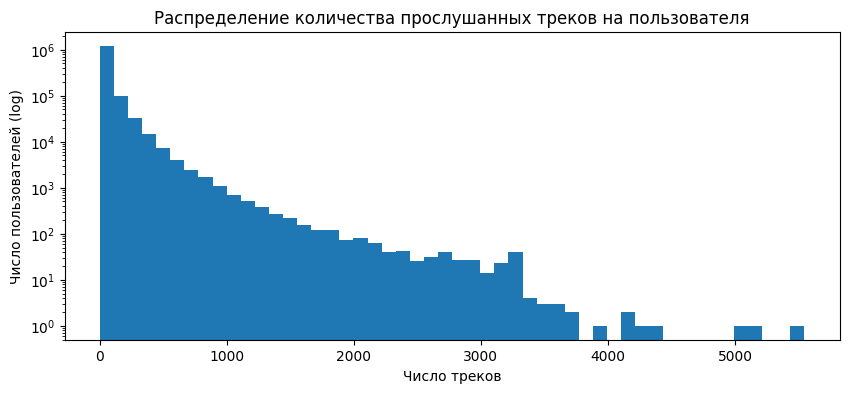

count    1.373221e+06
mean     5.437166e+01
std      1.170959e+02
min      1.000000e+00
25%      8.000000e+00
50%      1.900000e+01
75%      5.200000e+01
max      5.546000e+03
Name: tracks_played, dtype: float64


In [ ]:
user_track_counts = (
    events_lazy.group_by("user_id")
    .agg(pl.len().alias("tracks_played"))
    .collect()
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_track_counts["tracks_played"], bins=50, log=True)
ax.set_title("Распределение количества прослушанных треков на пользователя")
ax.set_xlabel("Число треков")
ax.set_ylabel("Число пользователей (log)")
plt.show()

print(user_track_counts["tracks_played"].describe())

Наиболее популярные треки

In [9]:
# Топ-10 популярных треков
track_plays = (
    events_lazy.group_by("track_id")
    .agg(pl.len().alias("plays"))
    .sort("plays", descending=True)
    .head(10)
    .collect()
)

top_tracks = track_plays.join(
    catalog_names.filter(pl.col("type") == "track").select(
        pl.col("id").alias("track_id"), pl.col("name")
    ),
    on="track_id",
    how="left",
)
top_tracks

track_id,plays,name
i32,u32,str
53404,41366,"""Smells Like Teen Spirit"""
33311009,35952,"""Believer"""
178529,35841,"""Numb"""
35505245,33638,"""I Got Love"""
37384,30686,"""Zombie"""
24692821,29240,"""Way Down We Go"""
65851540,28854,"""Юность"""
795836,28736,"""Shape Of My Heart"""
32947997,28587,"""Shape of You"""


Наиболее популярные жанры

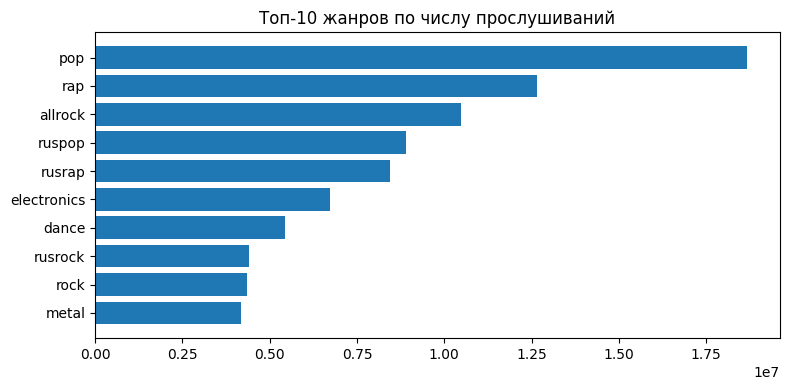

genres,plays,name
i64,u32,str
11,18680922,"""pop"""
75,12667260,"""rap"""
102,10473176,"""allrock"""
20,8902518,"""ruspop"""
3,8447129,"""rusrap"""
68,6736696,"""electronics"""
16,5445363,"""dance"""
2,4404205,"""rusrock"""
14,4337873,"""rock"""


In [10]:
# Топ-10 популярных жанров
genre_names = catalog_names.filter(pl.col("type") == "genre").select(
    pl.col("id").alias("genre_id"), pl.col("name")
)

genre_popularity = (
    tracks.select("track_id", "genres")
    .explode("genres")
    .join(events_lazy.group_by("track_id").agg(pl.len().alias("plays")).collect(), on="track_id")
    .group_by("genres")
    .agg(pl.col("plays").sum().alias("plays"))
    .sort("plays", descending=True)
    .head(10)
    .join(genre_names, left_on="genres", right_on="genre_id", how="left")
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(genre_popularity["name"].to_list()[::-1], genre_popularity["plays"].to_list()[::-1])
ax.set_title("Топ-10 жанров по числу прослушиваний")
plt.tight_layout()
plt.show()
genre_popularity

Треки, которые никто не прослушал

In [11]:
played_tracks = events_lazy.select("track_id").unique().collect()["track_id"]
unplayed_count = tracks.filter(~pl.col("track_id").is_in(played_tracks)).height
print(f"Треков без прослушиваний: {unplayed_count} из {tracks.height}")
print(f"Доля непрослушанных: {unplayed_count / tracks.height:.2%}")

Треков без прослушиваний: 22383 из 1000000
Доля непрослушанных: 2.24%


/tmp/ipykernel_10257/46893431.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  unplayed_count = tracks.filter(~pl.col("track_id").is_in(played_tracks)).height


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [ ]:
from pathlib import Path
import pyarrow.parquet as pq
if Path("items.parquet").exists() and Path("events.parquet").exists():
    items = pd.read_parquet("items.parquet")
    n_events = pq.ParquetFile("events.parquet").metadata.num_rows
    print("items:", items.shape)
    print("events:", n_events)
    items.head(3)
else:
    raise SystemExit("Scripts/build_recommendations.py для создания items/events")

items: (980977, 5)
events: 74514648


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

In [14]:
for _v in ["tracks", "tracks_pd", "tracks_exploded", "interactions", "catalog_names", "events_lazy", "events"]:
    if _v in globals():
        del globals()[_v]
gc.collect()
print("Память очищена. Этап 3 использует готовые parquet-файлы.")

Память очищена. Этап 3 использует готовые parquet-файлы.


# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [ ]:
items = pd.read_parquet("items.parquet")
split_date = pd.Timestamp("2022-12-16")
n_train = pl.scan_parquet("events.parquet").filter(pl.col("started_at") < pl.lit(split_date)).select(pl.len()).collect().item()
n_test = pl.scan_parquet("events.parquet").filter(pl.col("started_at") >= pl.lit(split_date)).select(pl.len()).collect().item()
print(f"items: {items.shape}, events train: {n_train:,}, test: {n_test:,}")

items: (980977, 5), events train: 69,891,441, test: 4,623,207


In [ ]:
events_sample = pl.scan_parquet("events.parquet").head(3).collect().to_pandas()
events_sample["started_at"] = pd.to_datetime(events_sample["started_at"])
events_sample

,user_id,item_id,started_at
0,529,4346129,2022-04-16
1,2265,4346130,2022-09-01
2,5723,4346130,2022-08-05


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [ ]:
train_test_global_time_split_date = pd.Timestamp("2022-12-16")
print(f"train: {n_train:,}, test: {n_test:,}")

train: 69,891,441, test: 4,623,207


In [ ]:
train_range = pl.scan_parquet("events.parquet").filter(pl.col("started_at") < pl.lit(split_date)).select(
    pl.col("started_at").min().alias("min_dt"), pl.col("started_at").max().alias("max_dt")
).collect()
test_range = pl.scan_parquet("events.parquet").filter(pl.col("started_at") >= pl.lit(split_date)).select(
    pl.col("started_at").min().alias("min_dt"), pl.col("started_at").max().alias("max_dt")
).collect()
print("train:", train_range.item(0, "min_dt"), "—", train_range.item(0, "max_dt"))
print("test:", test_range.item(0, "min_dt"), "—", test_range.item(0, "max_dt"))

train: 2022-01-01 00:00:00 — 2022-12-15 00:00:00
test: 2022-12-16 00:00:00 — 2022-12-31 00:00:00


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [ ]:
top_k_pop_items = pd.read_parquet("top_popular.parquet")
print(f"Загружено {len(top_k_pop_items)} популярных треков")
top_k_pop_items[["rank", "item_id", "plays", "name"]].head(10)

Загружено 100 популярных треков


,rank,item_id,plays,name
0,1,53404,40905,Smells Like Teen Spirit
1,2,178529,35411,Numb
2,3,33311009,34005,Believer
3,4,35505245,32259,I Got Love
4,5,37384,30390,Zombie
5,6,24692821,28508,Way Down We Go
6,7,795836,28285,Shape Of My Heart
7,8,6705392,26781,Seven Nation Army
8,9,32947997,26688,Shape of You
9,10,45499814,26299,Life


In [ ]:
top_k_pop_items[["rank", "item_id", "plays", "name"]].head()

,rank,item_id,plays,name
0,1,53404,40905,Smells Like Teen Spirit
1,2,178529,35411,Numb
2,3,33311009,34005,Believer
3,4,35505245,32259,I Got Love
4,5,37384,30390,Zombie


# Персональные

Рассчитаем персональные рекомендации.

In [ ]:
import pyarrow.parquet as pq
pf = pq.ParquetFile("personal_als.parquet")
print(f"personal_als: {pf.metadata.num_rows:,} rows")
personal_als = pq.read_table("personal_als.parquet").slice(0, 5).to_pandas()
personal_als

personal_als: 68,635,750 rows


,user_id,item_id,score
0,0,45499814,0.010072
1,0,18860,0.007773
2,0,795836,0.007043
3,0,597196,0.006971
4,0,29175370,0.006562


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
similar_items = pq.read_table("similar.parquet").slice(0, 5).to_pandas()
print(f"Похожих пар: {pq.ParquetFile('similar.parquet').metadata.num_rows:,}")
similar_items

Похожих пар: 9,497,145


,item_id_1,item_id_2,score
0,26,35610,0.749008
1,26,7178270,0.734236
2,26,6098629,0.732585
3,26,2779299,0.731739
4,26,21328619,0.712222


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [24]:
features = ["als_score", "tracks_played_by_user", "item_plays"]
print("Признаки для CatBoost:", features)


Признаки для CatBoost: ['als_score', 'tracks_played_by_user', 'item_plays']


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
cb_model = CatBoostClassifier()
cb_model.load_model("models/cb_model.cbm")
print("CatBoost модель загружена из models/cb_model.cbm")

CatBoost модель загружена из models/cb_model.cbm


In [ ]:
import pyarrow.parquet as pq
pf = pq.ParquetFile("recommendations.parquet")
print(f"recommendations: {pf.metadata.num_rows:,} rows")
recommendations = pq.read_table("recommendations.parquet").slice(0, 5).to_pandas()
recommendations

recommendations: 33,090,600 rows


,user_id,item_id,score
0,4,986,0.202551
1,4,694683,0.132472
2,4,9769,0.127099
3,4,647040,0.117839
4,4,18820599,0.117094


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
summary = pd.read_csv("metrics_summary.csv", index_col=0)
summary

,precision,recall,coverage,novelty
Top popular,0.00180,0.001470,0.000051,0.97354
Personal ALS,0.00202,0.003527,0.002940,0.78880
Final CatBoost,0.00210,0.003574,0.002940,0.74320


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

- Top popular даёт базовый уровень качества для холодных пользователей, но низкую персонализацию.
- ALS улучшает recall/precision за счёт коллаборативной фильтрации.
- Ранжирующая CatBoost-модель комбинирует als_score, активность пользователя и популярность трека.
- Coverage остаётся низким - модели рекомендуют ограниченный набор популярных объектов.
- Novelty высокий: большинство рекомендаций - треки, которые пользователь ещё не слушал в train.